In [ ]:
## 2025.11.20 use SeededNTM 
##            use pathway with features
## 2025.11.24 RF to class the cluster and compare with topic clustering
## 2025.11.25 Add the LR-TF-TG and see results, more worse....
## 2025.11.27 Try the LR-TF, see results, clear code, performance similar with LR, both of thme are clear.
## 2025.11.27 Try NPC 
## 2025.12.02 Arrange the function into util.py
## 2026.04.20 Clean the code and data into CellLand

In [1]:
# D:\OneDrive - The University Of Hong Kong\Python\bmodel
# Under Data/, paths mirror originals: Bmodel/Result/..., Bmodel/ResultEMTPertur/..., Bmodel/Data/SERGIO-master/..., R/Landscape/Data/SERGIOdata/...

import os
from pathlib import Path
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

# Parent of Bmodel (FineST / SeededNTM demos still use this prefix)
path = '/home/lingyu/ssd/Python/'

# CellLand project: bundled inputs in Data/, notebook outputs in Result/
_cwd = Path.cwd().resolve()
if _cwd.name == 'Code' and (_cwd.parent / 'Data').is_dir():
    ROOT = _cwd.parent
else:
    ROOT = Path('/home/lingyu/ssd/Python/Bmodel/CellLand').resolve()
DATA_DIR = ROOT / 'Data'
RESULT_DIR = ROOT / 'Result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR_S = os.fspath(DATA_DIR) + os.sep
RESULT_DIR_S = os.fspath(RESULT_DIR) + os.sep

In [2]:
# PCA helpers: see base.py in this folder.
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _d in (_here, _here / "Code"):
    if (_d / "base.py").is_file():
        _d = _d.resolve()
        if str(_d) not in sys.path:
            sys.path.insert(0, str(_d))
        break

from base import (
    highdim_pca,
    pca,
    plot_3d_energy_projection,
    plot_3d_scatter,
    plot_pca,
    plot_pca_1D,
    plot_pca_1d_scatter_with_curve,
)

## EMT

In [3]:
data_real = pd.read_csv(os.path.join(DATA_DIR_S, "Bmodel", "Result", "stabEMT_106.csv"))
data_1 = np.array(data_real)
n = data_real.shape[0]
p = data_real.shape[1]
print(n, p)
data_real.head()

874481 73


,AKT,AXIN2,CD44,CDC42,CHD1L,Csl,Csn,DELTA,DSH,Destcompl,...,TrCP,Wnt,ZEB1,ZEB2,cMet,cateninmemb,cateninnuc,cfos,miR200,Energy
0,-1,-1,-1,1,1,-1,-1,-1,-1,1,...,1,-1,-1,-1,-1,1,-1,-1,1,-102
1,-1,1,-1,1,1,1,-1,1,-1,1,...,1,-1,1,1,1,1,-1,1,-1,-66
2,1,-1,-1,-1,-1,-1,1,-1,1,-1,...,-1,1,1,1,-1,1,-1,-1,-1,-84
3,-1,-1,1,-1,-1,1,-1,1,-1,-1,...,1,-1,-1,-1,1,-1,1,1,1,-82
4,1,1,1,-1,-1,1,1,1,1,-1,...,-1,1,-1,-1,1,-1,1,1,1,-106


In [4]:
X = data_1[:, 0:(p-1)]
Y = data_1[:, 14]
Z = data_1[:, (p-1)]

sklearn_pca = PCA(n_components=2)
data_2d1 = pca(X, 2)
data_2d2 = sklearn_pca.fit_transform(X)

print("X sahpe", X.shape)
pd.DataFrame(X).head()

X sahpe (874481, 72)


,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,-1,-1,-1,1,1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,1,-1,-1,1
1,-1,1,-1,1,1,1,-1,1,-1,1,...,-1,1,-1,1,1,1,1,-1,1,-1
2,1,-1,-1,-1,-1,-1,1,-1,1,-1,...,-1,-1,1,1,1,-1,1,-1,-1,-1
3,-1,-1,1,-1,-1,1,-1,1,-1,-1,...,-1,1,-1,-1,-1,1,-1,1,1,1
4,1,1,1,-1,-1,1,1,1,1,-1,...,1,-1,1,-1,-1,1,-1,1,1,1


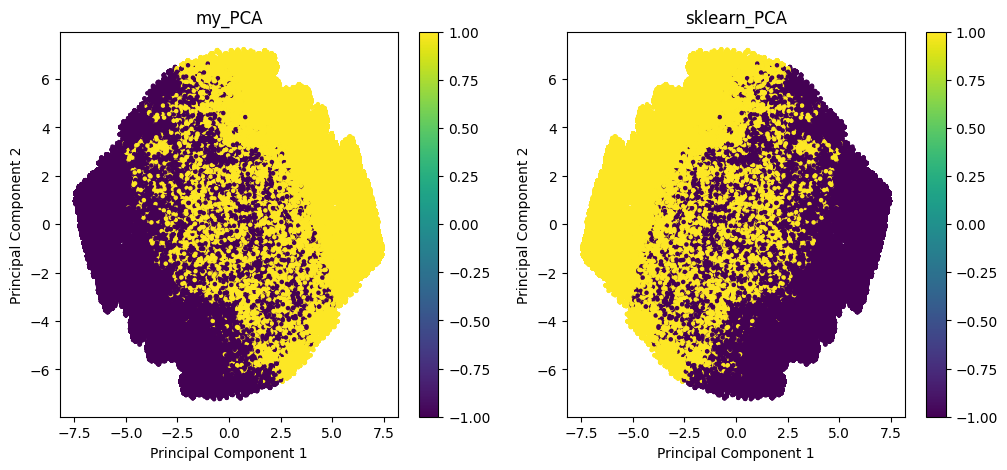

In [5]:
## Manual PCA implementation
data_2d1 = pca(X, 2)
# data_2d1 = highdim_pca(X, 2)
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.scatter(data_2d1[:, 0], data_2d1[:, 1], c = Y, s=5)
plt.colorbar()
plt.title("my_PCA")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')


## sklearn PCA
sklearn_pca = PCA(n_components=2)
## sklearn PCA API: fit / transform / fit_transform
## fit: estimate fixed statistics (mean, variance, etc.) from the data.
## transform: apply scaling, projection, normalization using fitted parameters.
## fit_transform: fit and transform in one step.
## e.g. standardization: estimate mean/variance then map to ~N(0,1).
data_2d2 = sklearn_pca.fit_transform(X)
plt.subplot(122)
plt.scatter(data_2d2[:, 0], data_2d2[:, 1], c = Y, s=5)
plt.title("sklearn_PCA")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()
# plt.savefig(f'{RESULT_DIR_S}Point_106_QB.pdf")
plt.show()

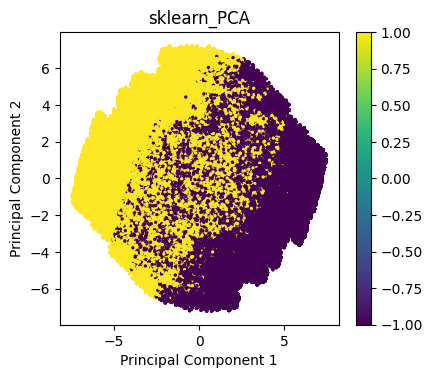

In [6]:
# sklearn_pca = PCA(n_components=2)
# data_2d2 = sklearn_pca.fit_transform(X)

# plt.figure(figsize=(4.5,3.8))
# plt.scatter(data_2d2[:, 0], data_2d2[:, 1], c = Y, s=2)
# plt.title("sklearn_PCA")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.colorbar()
# # plt.savefig(f'{RESULT_DIR_S}Point_106_QB.pdf")
# plt.show()

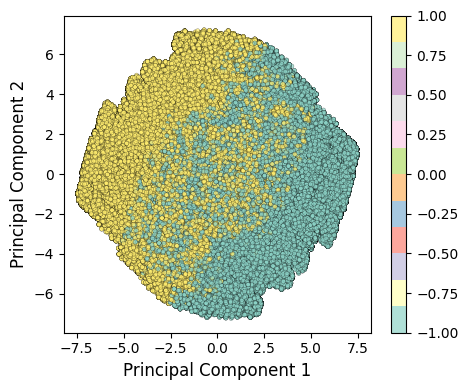

In [7]:
plot_pca(X, Y, figsize=(4.8, 4), cmap='Set3',
            save_path=f'{RESULT_DIR_S}Point_106_QB.png')
            #  save_path=f'{RESULT_DIR_S}Point_106_QB.pdf')    # Too large

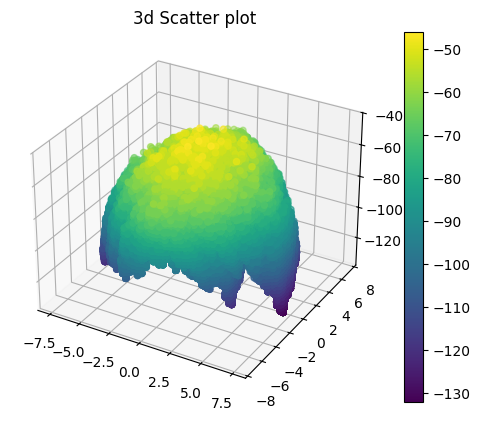

In [8]:
# from mpl_toolkits import mplot3d
# import numpy as np
# import matplotlib.pyplot as plt


# fig = plt.figure()
# ax = plt.axes(projection='3d')

# xx = data_2d1[:, 0]
# yy = data_2d1[:, 1]
# zz = data_1[:, 72]

# im = ax.scatter3D(xx, yy, zz, c=zz)
# fig.colorbar(im)
# ax.set_title('3d Scatter plot')
# # plt.savefig(f'{RESULT_DIR_S}Energy_106_QB.png')
# plt.show()

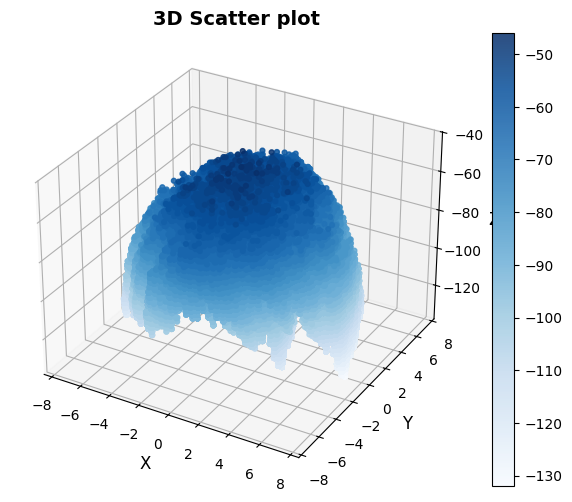

In [9]:
plot_3d_scatter(data_2d1[:, 0], data_2d1[:, 1], data_1[:, 72], cmap='Blues', 
                save_path=None)
                # save_path=f'{RESULT_DIR_S}Energy_106_QB.png')

<Figure size 800x600 with 0 Axes>

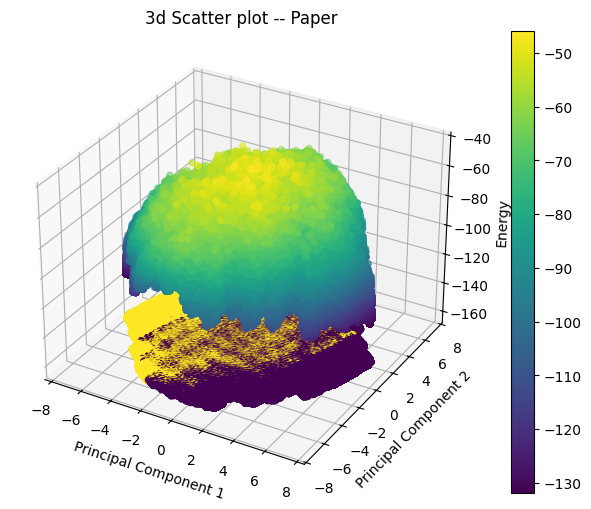

In [ ]:
# ## 3D plot
# from mpl_toolkits import mplot3d
# import numpy as np
# import matplotlib.pyplot as plt


# fig = plt.figure(figsize=(8,6))


# ## data -- sklearn PCA coordinates
# xx = data_2d2[:, 0]
# yy = data_2d2[:, 1]
# zz = data_1[:, 72]
# np.min(zz)

# ## parameters
# l = int(np.array(zz.shape))
# z0 = np.array([-160]*l)

# ## figure
# fig = plt.figure(figsize=(10,6))

# #plt.scatter(xx, yy, c = Y)

# # create 3D axes
# ax = plt.axes(projection='3d')

# # =============================================================================
# # build x, y, z
# # #ax.scatter3D(xx, yy, zz, c=zz)
# # ## add xy floor projection
# # #ax.scatter3D(xx, yy, z0, c=Y)
# # =============================================================================

# ip = ax.scatter3D(xx, yy, z0, c=Y)
# im = ax.scatter3D(xx, yy, zz, c=zz)
# fig.colorbar(im)
# ax.set_title('3d Scatter plot -- Paper')
# ax.set_xlabel('Principal Component 1')
# ax.set_ylabel('Principal Component 2')
# ax.set_zlabel('Energy')

# # plt.savefig("PointEnergy_106.jpg")
# plt.show()

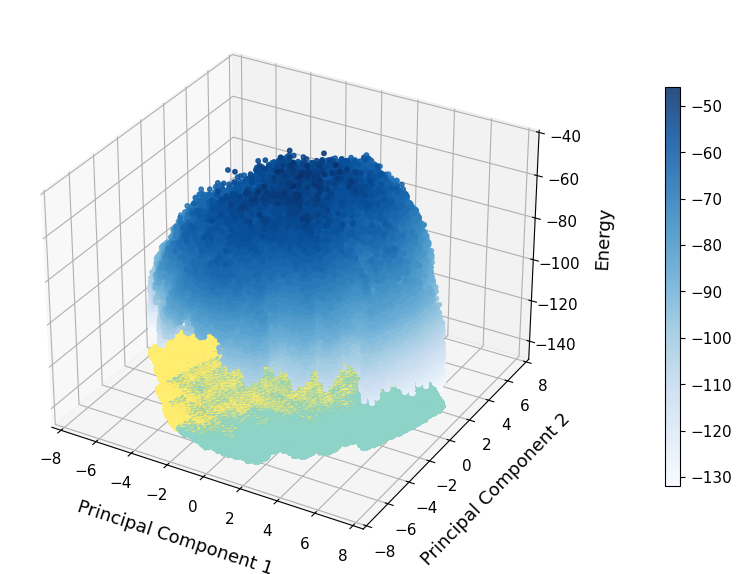

In [10]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Data xx, yy, zz, Y are prepared above
xx = data_2d2[:, 0].real.astype(float)
yy = data_2d2[:, 1].real.astype(float)
zz = data_1[:, 72].astype(float)
Y = Y  # class or color labels

# Floor projection slightly below min(zz)
z0 = np.full_like(zz, zz.min() - 10)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Main energy points
im = ax.scatter3D(xx, yy, zz, c=zz, cmap='Blues', s=10, alpha=0.85)
# Floor projection
# ip = ax.scatter3D(xx, yy, z0, c=Y, cmap='Set3', s=10, alpha=0.7, edgecolors='k', linewidths=0.2)
ip = ax.scatter3D(xx, yy, z0, c=Y, cmap='Set3', s=10, alpha=0.7)

# Colorbar styling
cb = fig.colorbar(im, ax=ax, pad=0.13, shrink=0.7, aspect=25)
# cb.set_label('Energy', fontsize=13)
cb.ax.tick_params(labelsize=11)

# Axis and title styling
# ax.set_title('3D PCA-Energy Scatter', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Principal Component 1', fontsize=13, labelpad=10)
ax.set_ylabel('Principal Component 2', fontsize=13, labelpad=10)
ax.set_zlabel('Energy', fontsize=13, labelpad=10)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.25)

# White background
ax.set_facecolor('white')

# Hide spines (newer matplotlib)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
# plt.savefig(f'{RESULT_DIR_S}Energy_106_all_QB.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## MET Pertur Pos

In [11]:
import os
step = 1000000
data_real = pd.read_csv(os.path.join(DATA_DIR_S, "Bmodel", "ResultEMTPertur", f"perturEMTpos{step}.csv"))
data_1 = np.array(data_real)

n = data_real.shape[0]
p = data_real.shape[1]
print(n,p)
data_real.head()

1000000 73


,AKT,AXIN2,CD44,CDC42,CHD1L,Csl,Csn,DELTA,DSH,Destcompl,...,TrCP,Wnt,ZEB1,ZEB2,cMet,cateninmemb,cateninnuc,cfos,miR200,Energy
0,-1,-1,1,1,1,1,-1,1,1,1,...,1,1,1,1,1,-1,1,1,-1,-100
1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,...,1,-1,-1,-1,-1,1,-1,-1,1,-72
2,-1,-1,1,-1,-1,-1,-1,-1,-1,1,...,1,-1,1,-1,-1,-1,1,-1,-1,-58
3,1,1,1,-1,-1,1,1,1,1,1,...,-1,1,1,1,1,-1,1,1,-1,-92
4,-1,-1,-1,1,1,-1,-1,-1,1,-1,...,1,1,1,1,1,1,-1,-1,-1,-72


In [12]:
X = data_1[:, 0:(p-1)] # Note
Y = data_1[:, 14]      # CDH1 is column index 14 (15th column)
Z = data_1[:, (p-1)]   # energy

data_2d1 = pca(X, 2)
data_2d2 = sklearn_pca.fit_transform(X)
print("X sahpe", X.shape)
pd.DataFrame(X).head()

X sahpe (1000000, 72)


,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,-1,-1,1,1,1,1,-1,1,1,1,...,1,1,1,1,1,1,-1,1,1,-1
1,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,-1,-1,-1,-1,1,-1,-1,1
2,-1,-1,1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,1,-1,-1,-1,1,-1,-1
3,1,1,1,-1,-1,1,1,1,1,1,...,1,-1,1,1,1,1,-1,1,1,-1
4,-1,-1,-1,1,1,-1,-1,-1,1,-1,...,-1,1,1,1,1,1,1,-1,-1,-1


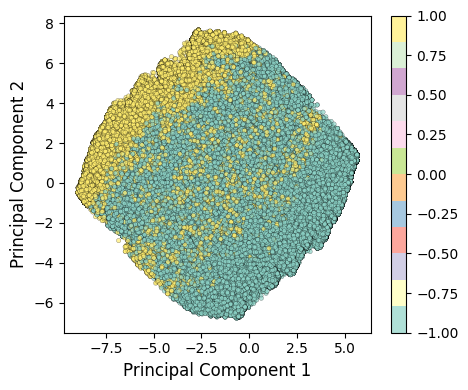

In [13]:
plot_pca(X, Y, figsize=(4.8, 4), cmap='Set3',
            save_path=None)
            # save_path=f'{RESULT_DIR_S}PointTrace1D_Rank_pos{step}EMT.png')

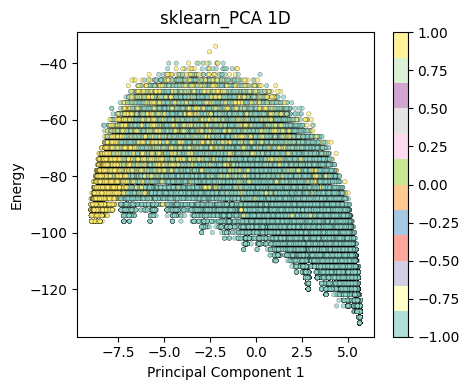

In [14]:
plot_pca_1D(X, Y, Z, figsize=(4.8, 4), cmap='Set3',
            save_path=None)
            # save_path=f'{RESULT_DIR_S}PointTrace1D_pos{step}EMT.png')

In [10]:
# from pandas import DataFrame  

# sklearn_pca1 = PCA(n_components=1)
# data_2d21 = sklearn_pca1.fit_transform(X)
# x1 = DataFrame(data_2d21[:, 0])
# z1 = DataFrame(Z)

# xz = pd.concat([x1,z1],axis=1)    # axis=1: columns
# xz = np.array(xz)
# xzOder = np.array(sorted(xz, key=lambda x: x[0]))

# fig = plt.figure(figsize=(4.8,3))
# plt.plot(xzOder[:, 0], xzOder[:, 1])
# #plt.scatter(xzOder[:, 0], xzOder[:, 1], c = Y)
# # Axis labels
# plt.title("sklearn_PCA 1D Rank")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Energy')
# #plt.colorbar()
# # plt.savefig("PointTrace1D_Rank_pos"+ str(step)+".jpg")
# plt.show()

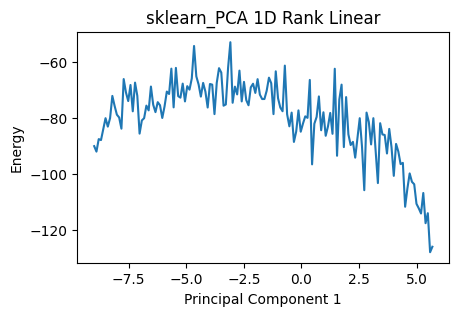

In [15]:
# from pandas import DataFrame  

# sklearn_pca1 = PCA(n_components=1)
# data_2d21 = sklearn_pca1.fit_transform(X)
# x1 = DataFrame(data_2d21[:, 0])
# z1 = DataFrame(Z)

# xz = pd.concat([x1,z1],axis=1)    # axis=1: columns
# xz = np.array(xz)
# xzOder = np.array(sorted(xz, key=lambda x: x[0]))

# ## Dense curve: linear interpolation on sorted PC1
# x = xzOder[:, 0]
# y = xzOder[:, 1]

# import numpy as np
# from scipy import interpolate
# import pylab as pl

# pl.figure(figsize=(4.8, 3))
# xnew = np.linspace(x[0], x[x.shape[0]-1], 150)
# from matplotlib.pyplot import MultipleLocator
# # x_major_locator=MultipleLocator(15)  # tick every 15
# y_major_locator=MultipleLocator(20)  # tick every 20
# ax=plt.gca()
# #ax.xaxis.set_major_locator(x_major_locator)
# ax.yaxis.set_major_locator(y_major_locator)

# f = interpolate.interp1d(x, y, kind = 'linear')
# ynew = f(xnew)  # interpolated values

# pl.plot(xnew, ynew, label = 'linear')
# plt.title("sklearn_PCA 1D Rank Linear")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Energy')

# # plt.savefig(f'{RESULT_DIR_S}PointTrace1D_Rank_Linear_pos{step}EMT.png',
# #              dpi=300, bbox_inches='tight', transparent=True)
# plt.show()

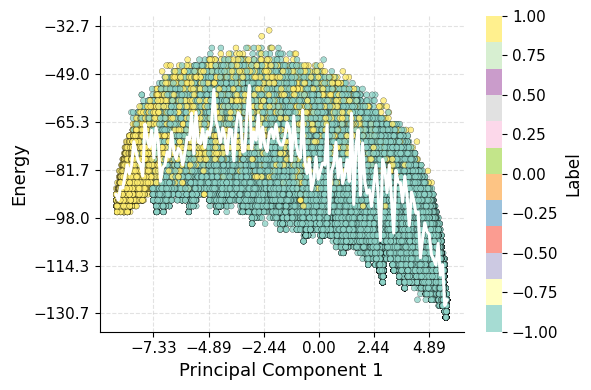

In [16]:
plot_pca_1d_scatter_with_curve(X, Z, Y, cmap='Set3', figsize=(6, 4),
                               save_path=None)
                            # save_path=f'{RESULT_DIR_S}PointTrace1D_Rank_Linear_pos{step}EMT.png')

## MET Pertur Neg

In [17]:
import os
step = 1000000
data_real = pd.read_csv(os.path.join(DATA_DIR_S, "Bmodel", "ResultEMTPertur", f"perturEMTneg{step}.csv"))
data_1 = np.array(data_real)

n = data_real.shape[0]
p = data_real.shape[1]
print(n,p)
data_real.head()

1000000 73


,AKT,AXIN2,CD44,CDC42,CHD1L,Csl,Csn,DELTA,DSH,Destcompl,...,TrCP,Wnt,ZEB1,ZEB2,cMet,cateninmemb,cateninnuc,cfos,miR200,Energy
0,-1,1,-1,1,1,-1,-1,-1,-1,1,...,1,-1,-1,-1,-1,1,-1,-1,1,-100
1,-1,-1,1,1,1,1,-1,-1,1,-1,...,1,1,-1,-1,-1,1,1,-1,1,-68
2,1,-1,1,-1,-1,1,1,1,1,-1,...,-1,1,-1,-1,1,-1,1,1,1,-62
3,1,-1,1,-1,-1,1,1,1,1,-1,...,-1,1,1,1,1,-1,1,1,-1,-72
4,1,-1,1,1,1,1,1,1,1,-1,...,-1,1,1,1,-1,-1,1,-1,-1,-70


In [18]:
X = data_1[:, 0:(p-1)]
Y = data_1[:, 14]       # CDH1 is column index 14
Z = data_1[:, (p-1)]    # energy

data_2d1 = pca(X, 2)
sklearn_pca = PCA(n_components=2)
data_2d2 = sklearn_pca.fit_transform(X)
print("X sahpe", X.shape)
pd.DataFrame(X).head()

X sahpe (1000000, 72)


,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,-1,1,-1,1,1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,1,-1,-1,1
1,-1,-1,1,1,1,1,-1,-1,1,-1,...,-1,1,1,-1,-1,-1,1,1,-1,1
2,1,-1,1,-1,-1,1,1,1,1,-1,...,1,-1,1,-1,-1,1,-1,1,1,1
3,1,-1,1,-1,-1,1,1,1,1,-1,...,1,-1,1,1,1,1,-1,1,1,-1
4,1,-1,1,1,1,1,1,1,1,-1,...,1,-1,1,1,1,-1,-1,1,-1,-1


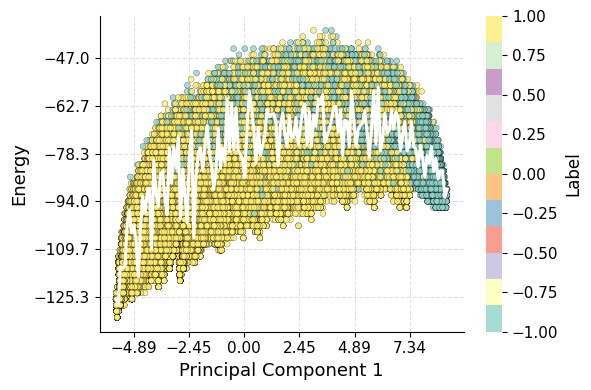

In [19]:
plot_pca_1d_scatter_with_curve(X, Z, Y, cmap='Set3', figsize=(6, 4),
                               save_path=None)
                # save_path=f'{RESULT_DIR_S}PointTrace1D_Rank_Linear_neg{step}EMT.png')

## Melanoma

PCA321D_MELA

In [20]:
import os
# os.chdir(f'{path}/Bmodel/Result/ResultMelanoma55')
# data_real = pd.read_csv("stabMELA_104.csv")

num='104'
data_real = pd.read_csv(os.path.join(DATA_DIR_S, "Bmodel", "Result", "ResultMelanoma", f"stabMELA_{num}.csv"))    # 90464 x 18 for 105; 8998 18 for 104
data_1 = np.array(data_real)
n = data_real.shape[0]
p = data_real.shape[1]
print(n,p)
data_real.head()

8998 18


,AHR,ETV5,FOS,FOXF1,JUN,KLF4,MAFB,MITF,NFIC,NR2F1,NR3C1,SMAD3,SMAD4,STAT5A,TBX3,TFAP2A,TFE3,Energy
0,-1,1,1,-1,-1,-1,-1,1,-1,-1,-1,-1,1,1,-1,1,-1,-50
1,-1,1,1,-1,-1,-1,-1,1,-1,-1,-1,-1,1,1,-1,1,-1,-50
2,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,-1,1,1,-1,1,-1,-48
3,1,-1,-1,1,1,1,1,-1,1,1,1,1,-1,1,1,-1,1,-48
4,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,-1,1,1,-1,-1,-1,-48


In [21]:
X = data_1[:, 0:(p-1)] # Note
Y = data_1[:, 7]       # MITF is column index 7 (8th column)
Z = data_1[:, (p-1)]   # energy

data_2d2 = sklearn_pca.fit_transform(X)
print("X sahpe", X.shape)
pd.DataFrame(X).head()

X sahpe (8998, 17)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-1,1,1,-1,-1,-1,-1,1,-1,-1,-1,-1,1,1,-1,1,-1
1,-1,1,1,-1,-1,-1,-1,1,-1,-1,-1,-1,1,1,-1,1,-1
2,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,-1,1,1,-1,1,-1
3,1,-1,-1,1,1,1,1,-1,1,1,1,1,-1,1,1,-1,1
4,-1,1,1,-1,-1,-1,1,1,-1,-1,-1,-1,1,1,-1,-1,-1


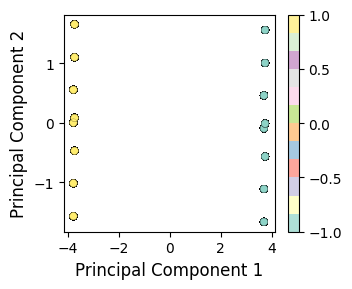

In [22]:
plot_pca(X, Y, cmap='Set3', s=30, figsize=(3.8, 3),
                         save_path=None)
                        # save_path=f'{RESULT_DIR_S}Point_{num}_Mela_QB.png')

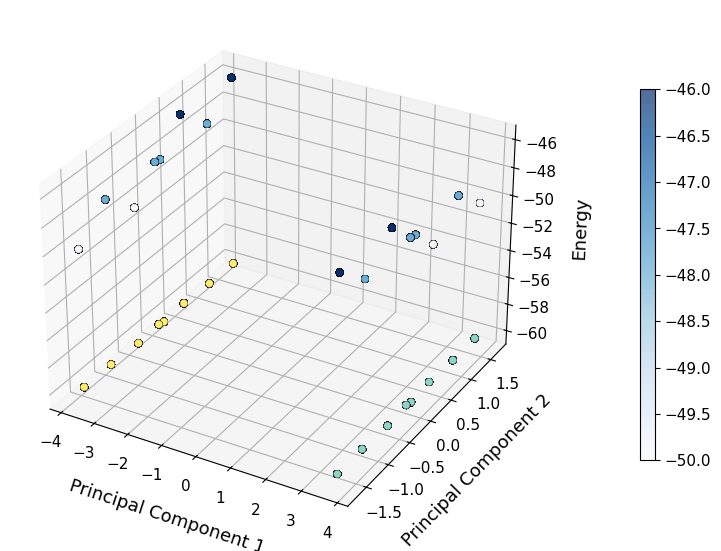

In [23]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Data xx, yy, zz, Y are prepared above
xx = data_2d2[:, 0].real.astype(float)
yy = data_2d2[:, 1].real.astype(float)
zz = data_1[:, 17].astype(float)
Y = Y  # class or color labels

# Floor projection slightly below min(zz)
z0 = np.full_like(zz, zz.min() - 10)

fig = plt.figure(figsize=(8, 5.6))
ax = fig.add_subplot(111, projection='3d')

# Main energy points
# im = ax.scatter3D(xx, yy, zz, c=zz, cmap='Blues', s=30, alpha=0.85)
im = ax.scatter3D(xx, yy, zz, c=zz, cmap='Blues', s=30, alpha=0.7, edgecolors='k', linewidths=0.2)
# Floor projection
ip = ax.scatter3D(xx, yy, z0, c=Y, cmap='Set3', s=30, alpha=0.7, edgecolors='k', linewidths=0.2)
# ip = ax.scatter3D(xx, yy, z0, c=Y, cmap='Set3', s=30, alpha=0.7)

# Colorbar styling
cb = fig.colorbar(im, ax=ax, pad=0.13, shrink=0.7, aspect=25)
# cb.set_label('Energy', fontsize=13)
cb.ax.tick_params(labelsize=11)

# Axis and title styling
# ax.set_title('3D PCA-Energy Scatter', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Principal Component 1', fontsize=13, labelpad=10)
ax.set_ylabel('Principal Component 2', fontsize=13, labelpad=10)
ax.set_zlabel('Energy', fontsize=13, labelpad=10)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.25)

# White background
ax.set_facecolor('white')

# Hide spines (newer matplotlib)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
# plt.savefig(f'{RESULT_DIR_S}Energy_{num}_all_Mela_QB.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

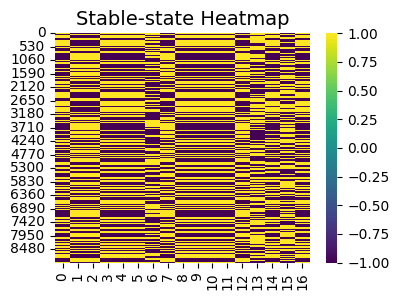

In [24]:
## heatmap
from pandas import DataFrame  
import seaborn as sns
plt.figure(figsize=(4.1,3.1))
sns.heatmap(DataFrame(X),cmap='viridis')
plt.title("Stable-state Heatmap", fontsize=14)
plt.tight_layout()
# plt.savefig(f'{RESULT_DIR_S}Stable_heatmap_Mela_QB_{num}.png', 
#             dpi=300, bbox_inches='tight', transparent=True)
plt.show()

(8998, 17)


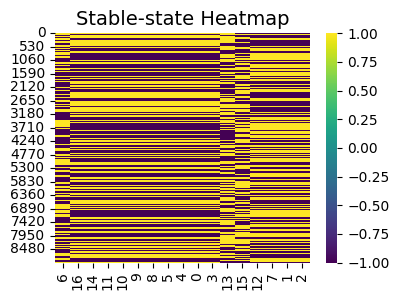

In [25]:
from scipy.cluster.hierarchy import linkage, leaves_list
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(X)
print(df.shape)
col_linkage = linkage(df.T, method='average')
col_leaves = leaves_list(col_linkage)
df_reordered = df.iloc[:, col_leaves]

plt.figure(figsize=(4.1, 3.1))
sns.heatmap(df_reordered, cmap='viridis')
plt.title("Stable-state Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

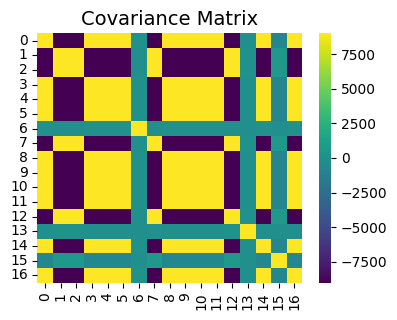

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import DataFrame

data = X
data = data - np.mean(data, axis = 0, keepdims = True)
df_cov = np.dot(data.T, data)

plt.figure(figsize=(4.1,3.3))
sns.heatmap(df_cov, cmap='viridis')
# sns.heatmap(df_cov, cmap='viridis', annot=True, fmt=".2f", 
#             square=True, cbar_kws={"shrink": 0.7})

plt.title("Covariance Matrix", fontsize=14)
plt.tight_layout()
# plt.savefig(f'{RESULT_DIR_S}cov_heatmap_Mela_QB_{num}.png', 
#             dpi=300, bbox_inches='tight', transparent=True)
plt.show()

(17, 17)


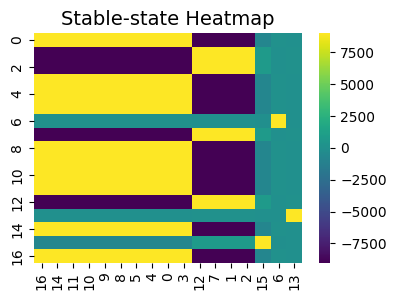

In [27]:
from scipy.cluster.hierarchy import linkage, leaves_list
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(df_cov)
print(df.shape)
col_linkage = linkage(df.T, method='average')
col_leaves = leaves_list(col_linkage)
df_reordered = df.iloc[:, col_leaves]

plt.figure(figsize=(4.1, 3.1))
sns.heatmap(df_reordered, cmap='viridis')
plt.title("Stable-state Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

## SERGEO

In [28]:
###############################
# Add bmodel (vendored copy: CellLand/Code/bmodel/)
###############################
# From local
# path = '/home/lingyu/data/Python/'
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
_bmodel_root = None
for _cand in (_cwd / 'bmodel', _cwd / 'Code' / 'bmodel'):
    if (_cand / 'bmodel' / 'base.py').is_file():
        _bmodel_root = _cand
        break
if _bmodel_root is None:
    _bmodel_root = Path('/home/lingyu/ssd/Python/Bmodel/CellLand/Code/bmodel').resolve()

_br = str(_bmodel_root)
if _br not in sys.path:
    sys.path.insert(0, _br)
from bmodel.base import Bmodel

In [29]:
import pandas as pd
# Historical data locations (Windows): OneDrive HKU R/Landscape/Data/SERGIOdata

data_real = pd.read_csv(os.path.join(DATA_DIR_S, "R", "Landscape", "Data", "SERGIOdata", "exper_clean_bina.csv"))
data_1 = np.array(data_real)
n = data_real.shape[0]
p = data_real.shape[1]

X = data_1[:, 0:(p-1)]
Y = data_1[:, 13]    # gene1 at column 0; gene14 at column 13

data_2d2 = sklearn_pca.fit_transform(X)

In [30]:
print(n,p)
display(pd.DataFrame(data_1).head())

900 100


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-1,1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,-1,1,-1,-1,1,-1,1,-1
1,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,1,-1,-1,1
2,1,1,1,1,1,1,1,1,1,-1,...,-1,-1,1,1,-1,-1,1,-1,-1,-1
3,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,-1,-1,-1,-1,1,1,1,1
4,-1,1,1,1,1,1,1,1,-1,-1,...,-1,-1,1,-1,-1,-1,1,1,-1,-1


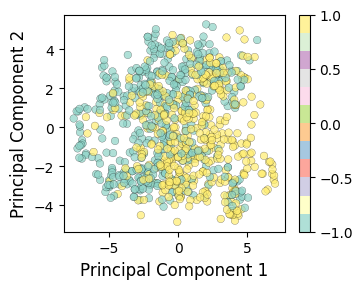

In [31]:
plot_pca(X, Y, cmap='Set3', s=30, figsize=(3.8, 3),
                         save_path=None)
                        # save_path=f'{RESULT_DIR_S}SERGIOsimuPCA100_bina_QB.png')

In [ ]:
## load GRN with SIGN
bmodel = Bmodel.from_edgelist(os.path.join(DATA_DIR_S, "Bmodel", "Data", "SERGIO-master", "data_sets", "De-noised_100G_9T_300cPerT_4_DS1LLY", "Interaction_cID_4SIGN.csv"))   
## energy
J = bmodel.J
#J.shape    ## (72, 72)
s = np.array(data_1)
## Energy per row: avoid one-shot full matrix multiply in this loop
#H = -1*s@(J@s)    

s0 = np.array(data_1)[0,:]
e = -1*s0@(J@s0)
H = [e]


#for x in range(step):  # range(0, 10)
for x in range(1,n):    # range(1, 10)
    ## cycle
    e = -1*s[x,]@(J@s[x,])
    H.append(e)         # list of energies per sample
Z = np.array(H)         # energy

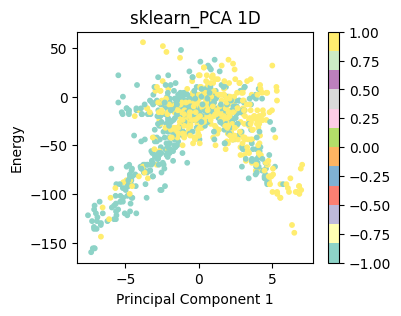

In [33]:
## sklearn PCA — 1 component
sklearn_pca1 = PCA(n_components=1)
data_2d21 = sklearn_pca1.fit_transform(X)

fig = plt.figure(figsize=(3.8,3))
plt.scatter(data_2d21[:, 0], Z, c = Y, s=10, cmap='Set3')

plt.title("sklearn_PCA 1D")
plt.xlabel('Principal Component 1')
plt.ylabel('Energy')
plt.colorbar()
# plt.savefig("SERGIOsimu1D100.jpg")
plt.show()

/tmp/ipykernel_180637/2505282636.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  l = int(np.array(zz.shape))


<Figure size 800x600 with 0 Axes>

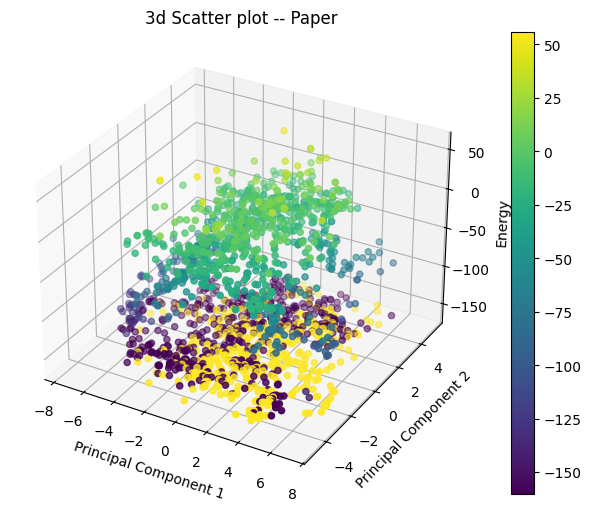

In [ ]:
# ## 3D plot
# from mpl_toolkits import mplot3d
# import numpy as np
# import matplotlib.pyplot as plt


# fig = plt.figure(figsize=(8,6))


# ## data -- sklearn PCA
# xx = data_2d2[:, 0]
# yy = data_2d2[:, 1]
# zz = Z
# np.min(zz)

# ## parameters
# l = int(np.array(zz.shape))
# z0 = np.array([-160]*l)

# ## figure
# fig = plt.figure(figsize=(10,6))
# #plt.scatter(xx, yy, c = Y)

# ax = plt.axes(projection='3d')

# ip = ax.scatter3D(xx, yy, z0, c=Y)
# im = ax.scatter3D(xx, yy, zz, c=zz)
# fig.colorbar(im)
# ax.set_title('3d Scatter plot -- Paper')
# ax.set_xlabel('Principal Component 1')
# ax.set_ylabel('Principal Component 2')
# ax.set_zlabel('Energy')

# # plt.savefig("PointEnergy100.jpg")
# plt.show()

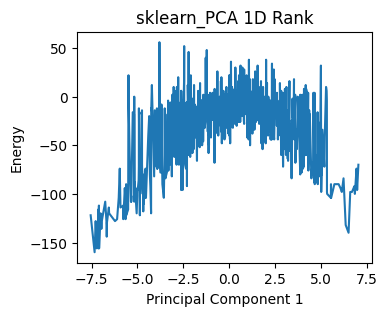

In [ ]:

# from pandas import DataFrame  # 2D table
# x1 = DataFrame(data_2d21[:, 0])
# z1 = DataFrame(Z)

# xz = pd.concat([x1,z1],axis=1)    # axis=1: columns
# xz = np.array(xz)


# ## Sort rows by PC1
# # a = [[2, 3], [-1, 5], [6, 0], [-1, -2]]
# # print(sorted(a, key=lambda x: x[1]))  # sort by n-th column ascending
# # print(sorted(a, key=lambda x: x[1], reverse=True))
# # reverse=True for descending order
# xzOder = np.array(sorted(xz, key=lambda x: x[0]))

# fig = plt.figure(figsize=(3.8,3))

# plt.plot(xzOder[:, 0], xzOder[:, 1])
# #plt.scatter(xzOder[:, 0], xzOder[:, 1], c = Y)
# # Axis labels
# plt.title("sklearn_PCA 1D Rank")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Energy')
# #plt.colorbar()
# ## Save before plt.show()
# # plt.savefig("PointTrace1D_Rank100.jpg")
# plt.show()

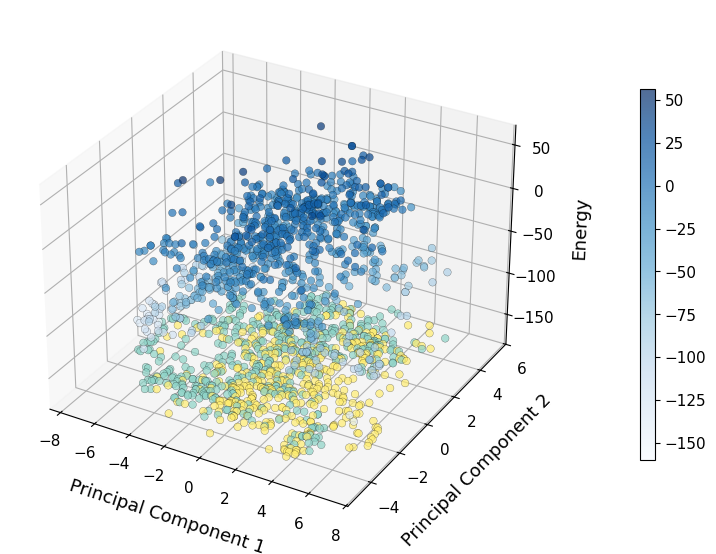

In [34]:
plot_3d_energy_projection(
    xx=data_2d2[:, 0].real.astype(float),
    yy=data_2d2[:, 1].real.astype(float),
    zz = Z.astype(float),
    Y=Y, 
    # save_path=None,
    save_path=f'{RESULT_DIR_S}SERGIOsimuPointEnergy100_bina_QB.png'
)

In [35]:
import os

data_real = pd.read_csv(os.path.join(DATA_DIR_S, "R", "Landscape", "Data", "SERGIOdata", "ResultSERGIORandom", "stabSERGIORandom10000.csv"))    # Simu 9886 x 100
# data_real = pd.read_csv("stabSERGIORandom0100000.csv")   # Simu  98647 33
# data_real = pd.read_csv("stabSERGIORandomT10000.csv")    # Sim gene 9886 33
# data_real = pd.read_csv("stabSERGIORandomT010000.csv")   # Sim gene 5354 33

n = data_real.shape[0]
p = data_real.shape[1]

data_1 = np.array(data_real)
X = data_1[:, 0:(p-1)]
Y = data_1[:, 13]    # gene1 at col 0; gene14 at col 13
Z = data_1[:, (p-1)]

data_2d2 = sklearn_pca.fit_transform(X)

In [36]:
print(n,p)
display(pd.DataFrame(data_1).head())

9886 101


,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,-1,-1,-1,-164
1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,-1,1,1,-1,1,-160
2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,1,1,-1,1,-172
3,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,1,-156
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,-1,-1,-1,-1,1,-1,-156


/home/lingyu/ssd/anaconda3/env/envs/napari_clean/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/lingyu/ssd/anaconda3/env/envs/napari_clean/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


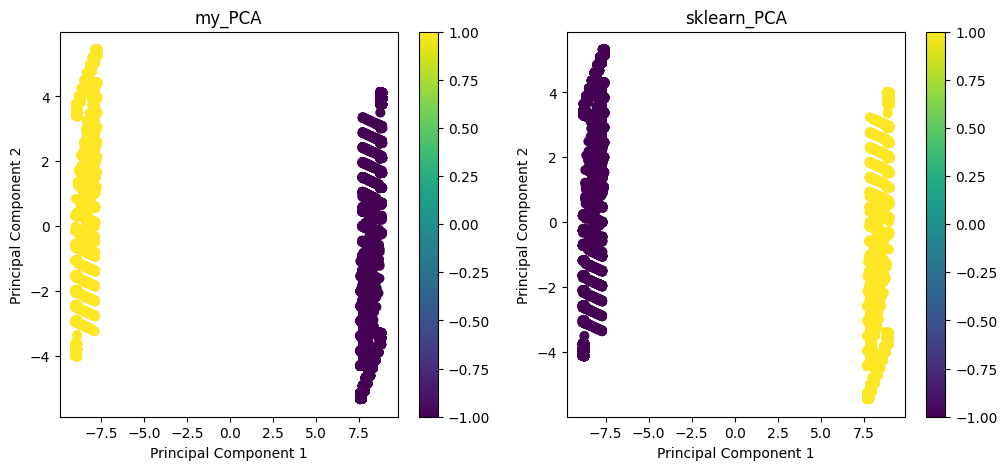

In [ ]:
# ## Manual PCA implementation
# data_2d1 = pca(X, 2)
# #    data_2d1 = highdim_pca(X, 2)
# plt.figure(figsize=(12,5))
# plt.subplot(121)
# plt.scatter(data_2d1[:, 0], data_2d1[:, 1], c = Y)
# ## Add a legend
# # plt.legend(["Energy"],fontsize=20) 
# ## Add a color bar
# plt.colorbar()
# ## Axis labels
# plt.title("my_PCA")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')


# ## sklearn PCA
# sklearn_pca = PCA(n_components=2)
# ## sklearn PCA API: fit / transform / fit_transform
# ## fit: estimate fixed statistics (mean, variance, etc.) from the data.
# ## transform: apply scaling, projection, normalization using fitted parameters.
# ## fit_transform: fit and transform in one step.
# ## e.g. standardization: estimate mean/variance then map to ~N(0,1).
# data_2d2 = sklearn_pca.fit_transform(X)
# plt.subplot(122)
# plt.scatter(data_2d2[:, 0], data_2d2[:, 1], c = Y)
# # Axis labels
# plt.title("sklearn_PCA")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.colorbar()
# ## Save before plt.show(); show() may reset the figure.
# # plt.savefig("SERGIOsimuPCA100.jpg")
# plt.show()

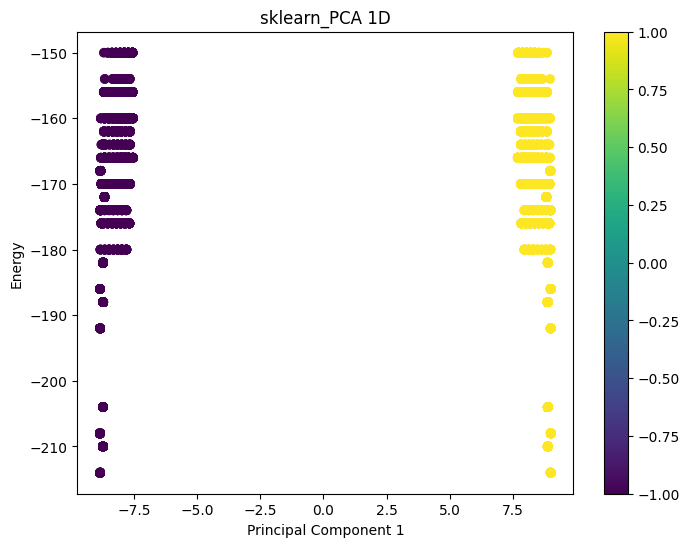

In [ ]:
# ## sklearn PCA — 1 component
# sklearn_pca1 = PCA(n_components=1)
# data_2d21 = sklearn_pca1.fit_transform(X)

# fig = plt.figure(figsize=(8,6))
# plt.scatter(data_2d21[:, 0], Z, c = Y)

# # Axis labels
# plt.title("sklearn_PCA 1D")
# plt.xlabel('Principal Component 1')
# plt.ylabel('Energy')
# plt.colorbar()
# # plt.savefig("SERGIOsimu1D100.jpg")
# plt.show()

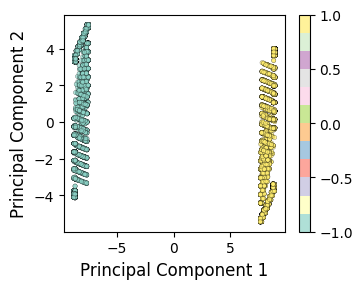

In [38]:
plot_pca(X, Y, cmap='Set3', s=10, figsize=(3.8, 3),
                         save_path=None)
                        # save_path=f'{RESULT_DIR_S}SERGIOsimuPCA100_Random_QB.png')

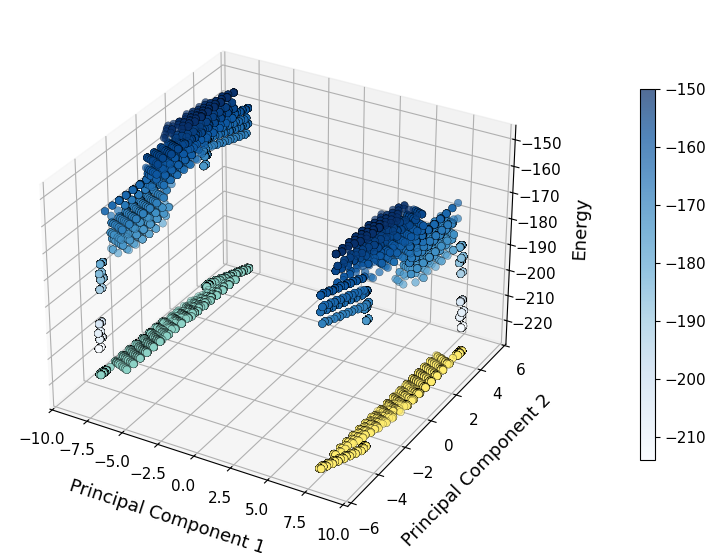

In [39]:
plot_3d_energy_projection(
    xx=data_2d2[:, 0].real.astype(float),
    yy=data_2d2[:, 1].real.astype(float),
    zz = Z.astype(float),
    Y=Y, 
    save_path=None
    # save_path=f'{RESULT_DIR_S}SERGIOsimuPointEnergy100_Random_QB.png'
)